In [411]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
# Aplicar configuraciones de visualización total de Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

from pathlib import Path
import glob

import warnings
warnings.filterwarnings("ignore")
import plotly.express as px

In [412]:
ruta_excel = r"data\bd_analisis.xlsx"

In [413]:
df_rot_gen = pd.read_excel(ruta_excel, sheet_name="rotacion_general")
df_rot_vol = pd.read_excel(ruta_excel, sheet_name="rotacion_voluntaria")

In [414]:
def graf_boxplot (df_rot_gen):

    fig = px.box(
        df_rot_gen,
        x="Año",
        y="rot_general",
        color="Año",
        points="all",  # Muestra todos los puntos individuales al lado de la caja
        title="Comparativa de Distribución de Valores: 2025 vs 2026",
        labels={
            "rot_general": "Métrica / Ratio",  # Corrección del mapeo para el eje Y
            "Año": "Año Fiscal"
        },
        color_discrete_sequence=px.colors.qualitative.Set2  # Paleta estética y clara
    )

    fig.update_layout(
        template="plotly_white",  # Fondo blanco minimalista
        title_font_size=16,
        title_x=0.5,               # Centra el título en el lienzo
        showlegend=False           # Oculta la leyenda redundante (el eje X ya indica el año)
    )

    fig.show()

def graf_histogram(df_rot_gen, colum):
    fig = px.histogram(
        df_rot_gen,
        x=colum,
        color="Año",
        barmode="overlay",
        marginal="box",
        opacity=0.7,
        title=f"Comparativa de Distribución de {colum}: 2025 vs 2026",
        # Configuración dinámica del tooltip
        hover_data={
            "Sede": True,       # Muestra la Sede
            "Mes": True,        # Muestra el Mes
            "Año": True,        # Muestra el Año
            colum: ":.4f"       # Formatea el valor de la columna a 4 decimales
        },
        labels={
            colum: "Métrica / Ratio",
            "Año": "Año Fiscal",
            "count": "Frecuencia",
            "Sede": "Tienda",
            "Mes": "Mes"
        },
        color_discrete_sequence=px.colors.qualitative.Set2
    )

    fig.update_layout(
        template="plotly_white",
        title_font_size=16,
        title_x=0.5,
        showlegend=True,
        legend_title_text="Año Fiscal",
        yaxis_title="Frecuencia",
        xaxis_title=colum
    )

    fig.show()

def graf_ranking_diff (df_rot_gen, colum):
    # Consolidar el promedio anual por sede y calcular la variación absoluta
    df_sedes = df_rot_gen.groupby(['Sede', 'Año'])['rot_general'].mean().unstack(level='Año')
    df_sedes['Variacion'] = df_sedes[2026] - df_sedes[2025]

    # Ordenar de mayor a menor incremento para identificar los principales causantes
    df_sedes = df_sedes.sort_values(by='Variacion', ascending=False).reset_index()
    df_sedes["Variacion"] = df_sedes["Variacion"]*100
    df_sedes["Variacion"] = df_sedes["Variacion"].astype(float).round(1)
    df_sedes[2025] = (df_sedes[2025]*100).astype(float).round(1)
    df_sedes[2026] = (df_sedes[2026]*100).astype(float).round(1)
    df_sedes

    import plotly.express as px
    # Aseguramos que los nombres de las columnas del año sean strings para evitar conflictos en el mapeo de labels
    df_sedes.columns = df_sedes.columns.astype(str)

    fig_bar = px.bar(
        df_sedes,
        x="Variacion",
        y=colum,
        orientation="h",
        title="Variación Absoluta de la Métrica (2026 vs 2025)",
        color="Variacion",
        color_continuous_scale=px.colors.diverging.Tealrose,
        # Incluimos las columnas de los años en el hover
        hover_data={
            "Variacion": ":.1f",  # Formato con 4 decimales
            "2025": ":.1f",
            "2026": ":.1f",
            colum: True
        },
        # Mapeo de etiquetas limpias para el tooltip y ejes
        labels={
            "Variacion": "Diferencia",
            "2025": "Promedio 2025",
            "2026": "Promedio 2026",
            colum: "Tienda"
        }
    )

    fig_bar.update_layout(
        template="plotly_white",
        yaxis={'categoryorder': 'total ascending'},
        title_x=0.5,
        xaxis_title="Diferencia (2026 - 2025)",
        height=max(400, len(df_sedes) * 20)
    )

    fig_bar.show()
    return df_sedes

In [415]:
# graf_boxplot (df_rot_gen)
# graf_histogram (df_rot_gen, "rot_general")
# graf_ranking_diff (df_rot_gen)

In [416]:
graf_boxplot (df_rot_vol)
graf_histogram (df_rot_vol, "rot_general")
graf_ranking_diff (df_rot_vol, "Sede")

Año,Sede,2025,2026,Variacion
0,Xvea Santa Cruz,16.5,29.5,13.0
1,Xvea Art Express,4.8,13.6,8.9
2,Svea La Paz,9.6,16.1,6.5
3,Svea Trujillo Valcarcel,5.3,11.8,6.5
4,Svea Corpac,8.3,14.1,5.9
...,...,...,...,...
109,Xvea Bolognesi,12.8,7.5,-5.3
110,Pvea Sjb Ayacucho,NaN,4.5,NaN
111,Svea Multiplaza,2.3,NaN,NaN
112,Tarapoto 2,NaN,5.3,NaN


In [417]:
df1 = df_rot_gen.groupby("Año")["rot_general"].median().reset_index()
df1["rot_general"] = (df1["rot_general"]*100).round(2)
print("RESULTADOS ROTACION GENERAL")
display(df1)
print("---------------------------")
df2 = df_rot_vol.groupby("Año")["rot_general"].median().reset_index()
df2["rot_general"] = (df2["rot_general"]*100).round(2)
print("RESULTADOS ROTACION VOLUNTARIA")
display(df2)

RESULTADOS ROTACION GENERAL


,Año,rot_general
0,2025,4.88
1,2026,5.88


---------------------------
RESULTADOS ROTACION VOLUNTARIA


,Año,rot_general
0,2025,4.94
1,2026,5.60


In [418]:
import pandas as pd
import plotly.express as px
def graf_rot_gen_vol(df_rot_gen, df_rot_vol, año):
    # 1. Filtrar para el año 2025 y extraer la serie de datos multiplicada por 100
    gen_2025 = df_rot_gen.loc[df_rot_gen["Año"] == año, "rot_general"] * 100
    vol_2025 = df_rot_vol.loc[df_rot_vol["Año"] == año, "rot_general"] * 100

    # 2. Construir un DataFrame consolidado en formato largo (long-format)
    df_compare = pd.DataFrame({
        "Valor": pd.concat([gen_2025, vol_2025], ignore_index=True),
        "Tipo Rotación": ["General"] * len(gen_2025) + ["Voluntaria"] * len(vol_2025)
    })
    year = str(año)
    # 3. Construcción del histograma comparativo
    fig = px.histogram(
        df_compare,
        x="Valor",
        color="Tipo Rotación",
        barmode="overlay",     # Superpone las barras para contrastar densidades
        marginal="box",        # Añade diagramas de caja marginales en la parte superior
        opacity=0.7,           # Transparencia para evaluar zonas de solapamiento
        
        title="Comparativa de Distribución: Rotación General vs. Voluntaria (Año " + year + " )",
        labels={
            "Valor": "Porcentaje de Rotación (%)",
            "Tipo Rotación": "Métrica",
            "count": "Frecuencia"
        },
        color_discrete_sequence=px.colors.qualitative.Safe  # Paleta con excelente contraste
    )

    # 4. Ajustes de diseño e idoneidad estética
    fig.update_layout(
        template="plotly_white",
        title_font_size=16,
        title_x=0.5,
        xaxis_title="Rotación (%)",
        yaxis_title="Frecuencia",
        legend_title_text="Tipo de Rotación"
    )

    fig.show()

In [419]:
graf_rot_gen_vol(df_rot_gen, df_rot_vol, 2025)

In [420]:
graf_rot_gen_vol(df_rot_gen, df_rot_vol, 2026)

In [421]:
df_rot_gen["llave"] = df_rot_gen["Sede"] + df_rot_gen["Año"].astype(str) + df_rot_gen["Mes"]
df_rot_vol["llave"] = df_rot_vol["Sede"] + df_rot_vol["Año"].astype(str) + df_rot_vol["Mes"]
df_rot_vol["rot_vol"] = df_rot_vol["rot_general"]

In [422]:
dff_merge1 = df_rot_gen.merge(df_rot_vol[["llave", "rot_vol"]], on="llave", how="left")
dff_merge1["Local"] = dff_merge1["Sede"]

In [423]:
dff_merge1["rot_otros"] = dff_merge1["rot_general"] - dff_merge1["rot_vol"]
dff_merge1

,Sede,Año,Mes,rot_general,llave,rot_vol,Local,rot_otros
0,Pvea Acho,2025,enero,0.1111,Pvea Acho2025enero,0.1111,Pvea Acho,0.0000
1,Pvea Acho,2025,febrero,0.0492,Pvea Acho2025febrero,0.0328,Pvea Acho,0.0164
2,Pvea Acho,2025,marzo,0.0794,Pvea Acho2025marzo,0.0635,Pvea Acho,0.0159
3,Pvea Acho,2025,abril,0.0678,Pvea Acho2025abril,0.0508,Pvea Acho,0.0170
4,Pvea Acho,2025,mayo,0.0690,Pvea Acho2025mayo,0.0517,Pvea Acho,0.0173
...,...,...,...,...,...,...,...,...
1109,Xvea Santa Cruz,2026,enero,0.4500,Xvea Santa Cruz2026enero,0.4500,Xvea Santa Cruz,0.0000
1110,Xvea Santa Cruz,2026,febrero,0.2353,Xvea Santa Cruz2026febrero,0.2353,Xvea Santa Cruz,0.0000
1111,Xvea Santa Cruz,2026,marzo,0.3333,Xvea Santa Cruz2026marzo,0.3333,Xvea Santa Cruz,0.0000
1112,Xvea Santa Cruz,2026,abril,0.4545,Xvea Santa Cruz2026abril,0.4545,Xvea Santa Cruz,0.0000


In [424]:
print(dff_merge1[dff_merge1["rot_otros"]>0]["Sede"].nunique())
graf_histogram (dff_merge1[dff_merge1["rot_otros"]>0], "rot_otros")

89


In [425]:
import func_gcp as func_gcp

In [426]:
query = "select * from spsa-operaciones-seg-sd.dst_gestion_operativa.bsc_local_atributos"

df_local = func_gcp.read_query_sdk(query)

In [427]:
df_local = df_local[~df_local["regional"].isnull()]
df_local

,codigo_local,formato,ubicacion,fecha_apertura,fecha_inicio_venta,fecha_inicio_sss,nombre,cluster,supervisor,regional,zona_1,tipo_sss,m2,zona_2,cluster_comercial,departamento,provincia
0,P048,PLAZA VEA,Lima + Callao,2002-02-27 00:00:00+00:00,2002-02-27 00:00:00+00:00,2003-03-01 00:00:00+00:00,Higuereta - PVH,A3,JOHANNA VILCA,Sebastián Santangelo,Lima Top,01,4577.0,Lima Metrop Oriente,BC3,Lima,Lima
1,V290,VIVANDA,Lima + Callao,2019-12-18 00:00:00+00:00,2019-12-18 00:00:00+00:00,2021-01-01 00:00:00+00:00,Asia - VIV,V2,María Rojas,María Rojas,Lima Sur,02,2298.0,Resto Peru Sur,V2,Lima,Cañete
4,P146,PLAZA VEA,Provincia,2010-11-03 00:00:00+00:00,2010-11-03 00:00:00+00:00,2011-12-01 00:00:00+00:00,Tacna - PVH,B3,JOE HUAMANCONDOR,Sofía Villanueva,Resto Provincias,01,3903.0,Resto Peru Sur,BC3,Tacna,Tacna
5,V116,VIVANDA,Lima + Callao,2008-06-23 00:00:00+00:00,2008-06-23 00:00:00+00:00,2009-07-01 00:00:00+00:00,Javier Prado - VIV,V1,María Rojas,María Rojas,Lima Moderna,01,1152.0,Lima Metrop Norte,A1,Lima,Lima
6,P123,PLAZA VEA,Provincia,2009-04-28 00:00:00+00:00,2009-04-28 00:00:00+00:00,2010-05-01 00:00:00+00:00,El Chacarero - PVH,C3,MELANY ALVARADO,Sofía Villanueva,Trujillo,01,4442.0,Trujillo,BC3,La Libertad,Trujillo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,P159,PLAZA VEA,Lima + Callao,2012-11-15 00:00:00+00:00,2012-11-15 00:00:00+00:00,2013-12-01 00:00:00+00:00,Acho - PVH,C2,VIK ENCISO,Sebastián Santangelo,Lima Antigua,01,3050.0,LIMA CENTRO,BC2,Lima,Lima
142,P080,PLAZA VEA,Lima + Callao,2004-08-01 00:00:00+00:00,2004-08-01 00:00:00+00:00,2005-08-01 00:00:00+00:00,Bolichera - PVH,B3,RODOLFO OLIVRY,Sebastián Santangelo,Lima Top,01,4271.0,Lima Metrop Oriente,BC3,Lima,Lima
143,P202,PLAZA VEA,Lima + Callao,2011-10-01 00:00:00+00:00,2011-10-01 00:00:00+00:00,2012-10-01 00:00:00+00:00,LurIn - PVH,B3,RODOLFO OLIVRY,Sebastián Santangelo,Lima Sur,01,3660.0,Lima Cono Sur,BC3,Lima,Lima
144,P177,PLAZA VEA,Provincia,2012-02-21 00:00:00+00:00,2012-02-21 00:00:00+00:00,2013-03-01 00:00:00+00:00,Talara - PVH,B2,MELANY ALVARADO,Sofía Villanueva,Piura,01,2074.0,Resto Peru Norte,BC2,Piura,Talara


In [428]:
df_local["Sede"] = df_local["nombre"].str.split(" - ").str[0]
df_local["Sede"] = df_local["Sede"].str.upper()
df_local["Sede"].unique()
df_local1 = df_local[["Sede", "formato", "ubicacion", "cluster_comercial", "supervisor", "regional", "m2", "departamento", "codigo_local"]]

In [429]:
dff_merge1["Sede"] = dff_merge1["Sede"].str.upper()

In [430]:
mapeo_locales = {
    "AVENTURA SJL": "AVENTURA SJL",
    "BREÑA CENTENARIO": "BRENA",
    "CHICLAYO MALL": "CHICLAYO AV",
    "CUZCO QUOYLLUR": "CUSCO MALL",
    "CUZCO SAN ANTONIO": "CUSCO WANCHAQ",
    "EL TAMBO": "EL TAMBO HUANCAYO",
    "LA PLACITA": "VES PLACITA",
    "LA VICTORIA": "LA VICTORIA REGINA",
    "NUEVO CHIMBOTE": "NVO CHIMBOTE",
    "PVO HUANUCO": "HUANUCO",
    "PVO JAEN": "JAEN",
    "PVO PUCALLPA": "PUCALLPA",
    "PVO TARAPOTO": "TARAPOTO",
    "RIMAC": "RIMAC ALCAZAR",
    "SKA": "SUPERMERCADO SKA",
    "TALARA MALL": "TALARA"
}

In [431]:
dff_merge1["Sede"] = dff_merge1["Sede"].map(mapeo_locales).fillna(dff_merge1["Sede"])

In [432]:
import re

patron_siglas = r'\b(PVEA|SVEA|VIV|XVEA)\b'

for df in [dff_merge1, df_local1]:
    if "Sede" in df.columns:
        df["Sede"] = (
            df["Sede"]
            .astype(str)
            .str.replace(patron_siglas, "", regex=True, flags=re.IGNORECASE) # Quita palabras exactas
            .str.replace(r'[\r\n]+', ' ', regex=True)                      # Reemplaza saltos de línea por un espacio
            .str.strip()                                                   # Quita espacios en blanco al inicio y final
            .str.replace(r'\s+', ' ', regex=True)                          # Colapsa espacios múltiples internos a uno solo
        )

In [433]:

dff_merge2 = dff_merge1.merge(df_local1, on="Sede", how="left")


In [434]:
dff_merge2

dff_merge3 = (
    dff_merge2.groupby(
        [
            "Local", "formato", "ubicacion", "cluster_comercial", 
            "supervisor", "regional", "m2", "departamento", 
            "codigo_local", "Año"
        ],
        dropna=False  # Conserva los grupos que contengan NaNs en las columnas llave
    )
    .agg({"rot_general": "mean"})
    .reset_index()
)
dff_merge4 = dff_merge3.pivot( index=["Local", "codigo_local", "formato", "ubicacion", "cluster_comercial", "supervisor", "regional", "m2", "departamento"], columns='Año',  values='rot_general').reset_index()
dff_merge4

Año,Local,codigo_local,formato,ubicacion,cluster_comercial,supervisor,regional,m2,departamento,2025,2026
0,Pvea Acho,P159,PLAZA VEA,Lima + Callao,BC2,VIK ENCISO,Sebastián Santangelo,3050.0,Lima,0.07530,0.04086
1,Pvea Alfonso Ugarte,P118,PLAZA VEA,Lima + Callao,BC3,VIK ENCISO,Sebastián Santangelo,4358.0,Lima,0.03200,0.05552
2,Pvea Arequipa,P104,PLAZA VEA,Provincia,BC3,JOE HUAMANCONDOR,Sofía Villanueva,4120.0,Arequipa,0.04364,0.05500
3,Pvea Ate,P066,PLAZA VEA,Lima + Callao,BC3,RODOLFO OLIVRY,Sebastián Santangelo,4798.0,Lima,0.03756,0.05058
4,Pvea Aventura Sjl,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04782,0.05134
...,...,...,...,...,...,...,...,...,...,...,...
109,Viv Pardo,V019,VIVANDA,Lima + Callao,NaN,María Rojas,María Rojas,1111.0,Lima,NaN,0.08645
110,Viv Pezet,V090,VIVANDA,Lima + Callao,A1,María Rojas,María Rojas,920.0,Lima,0.05646,0.05424
111,Xvea Art Express,P422,PLAZA VEA SUPER,Lima + Callao,FP,Fátima León,Fátima León,713.0,Lima,0.02856,0.08190
112,Xvea Bolognesi,X209,PLAZA VEA EXPRESS,Lima + Callao,FP,Fátima León,Fátima León,343.0,Lima,0.07666,0.04516


In [435]:
def resumen_rot (dff_merge4, colum):
    dfff = dff_merge4.groupby(colum).agg({"Local":"nunique", 2025:"median", 2026:"median"}).reset_index()
    dfff[2026] = (dfff[2026]*100).round(1)
    dfff[2025] = (dfff[2025]*100).round(1)
    dfff["diff"] = ((dfff[2026]  - dfff[2025])).round(1)
    
    return dfff.sort_values(by="diff", ascending=False)

def resumen_rot1 (dff_merge4, colum):
    dfff = dff_merge4.groupby(colum).agg({2025:"median", 2026:"median"}).reset_index()
    dfff[2026] = (dfff[2026]*100).round(1)
    dfff[2025] = (dfff[2025]*100).round(1)
    dfff["diff"] = ((dfff[2026]  - dfff[2025])).round(1)
    
    return dfff.sort_values(by="diff", ascending=False)

In [436]:
resumen_rot (dff_merge4, "formato")

Año,formato,Local,2025,2026,diff
0,PLAZA VEA,67,4.8,5.7,0.9
2,PLAZA VEA SUPER,23,6.4,7.1,0.7
3,VIVANDA,8,7.7,8.1,0.4
1,PLAZA VEA EXPRESS,4,7.2,4.6,-2.6


In [437]:
resumen_rot (dff_merge4, "ubicacion")

Año,ubicacion,Local,2025,2026,diff
1,Provincia,34,3.5,4.8,1.3
0,Lima + Callao,68,6.6,6.8,0.2


In [438]:
resumen_rot (dff_merge4, "regional")

Año,regional,Local,2025,2026,diff
4,Sofía Villanueva,30,3.7,4.9,1.2
3,Sebastián Santangelo,37,5.7,6.3,0.6
2,María Rojas,8,7.7,8.1,0.4
1,Hernán Perroni,15,7.2,7.5,0.3
0,Fátima León,12,5.7,5.2,-0.5


In [439]:
resumen_rot (dff_merge4, "supervisor")

Año,supervisor,Local,2025,2026,diff
3,JOHANNA VILCA,8,7.2,9.6,2.4
7,PEPE ARAMBURU,11,3.6,6.0,2.4
4,MELANY ALVARADO,9,2.4,4.4,2.0
2,JOE HUAMANCONDOR,9,4.7,5.7,1.0
9,VIK ENCISO,16,5.1,6.0,0.9
8,RODOLFO OLIVRY,13,4.8,5.5,0.7
5,María Rojas,8,7.7,8.1,0.4
0,DANIEL RODRIGUEZ,15,7.2,7.5,0.3
1,Fátima León,12,5.7,5.2,-0.5
6,Melany Alvarado,1,2.3,NaN,NaN


In [440]:
resumen_rot (dff_merge4, "departamento")

Año,departamento,Local,2025,2026,diff
3,Cajamarca,2,3.1,5.5,2.4
14,San Martin,2,2.7,5.1,2.4
13,Puno,2,5.6,7.9,2.3
12,Piura,5,2.3,4.3,2.0
0,Ancash,1,2.7,4.4,1.7
7,Junin,1,5.0,6.6,1.6
17,Ucayali,1,2.9,4.4,1.5
15,Tacna,1,2.9,4.3,1.4
9,Lambayeque,1,0.8,2.0,1.2
4,Callao,4,4.8,6.0,1.2


In [441]:
valores_m2 = dff_merge4['m2'].dropna().values
bordes_optimos = np.histogram_bin_edges(valores_m2, bins='fd')
num_bins = len(bordes_optimos) - 1
print(f"Bordes óptimos sugeridos por Freedman-Diaconis: {bordes_optimos}")
print(f"Cantidad óptima de intervalos: {num_bins}")


Bordes óptimos sugeridos por Freedman-Diaconis: [ 293. 1424. 2555. 3686. 4817. 5948. 7079.]
Cantidad óptima de intervalos: 6


In [442]:
from sklearn.cluster import KMeans

def calcular_bordes_optimos(df, col, num_bins=4, metodo='cuantiles'):
    """
    Calcula los bordes óptimos para un número fijo de bins 'k'.
    Garantiza robustez estadística y manejo de NaNs.
    """
    # Vector de entrada limpio
    x = df[col].dropna().values
    
    if metodo == 'cuantiles':
        # Enfoque probabilístico: Distribución uniforme de frecuencias
        proporciones = np.linspace(0, 100, num_bins + 1)
        bordes = np.percentile(x, proporciones)
        
    elif metodo == 'kmeans':
        # Enfoque de optimización de varianza: Minimización de WCSS
        km = KMeans(n_clusters=num_bins, n_init='auto', random_state=42)
        km.fit(x.reshape(-1, 1))
        
        # Los bordes se definen como los puntos medios entre centroides ordenados
        centroides = np.sort(km.cluster_centers_.flatten())
        puntos_medios = (centroides[:-1] + centroides[1:]) / 2
        bordes = np.concatenate(([x.min()], puntos_medios, [x.max()]))
        
    else:
        raise ValueError("Método no reconocido. Elige 'cuantiles' o 'kmeans'.")
        
    # Corregir tolerancias numéricas en los extremos
    bordes[0] -= 1e-5
    bordes[-1] += 1e-5
    
    # Construcción óptima de etiquetas de rango string
    etiquetas = [f"{inf:.2f} - {sup:.2f}" for inf, sup in zip(bordes[:-1], bordes[1:])]
    
    return bordes, etiquetas

In [443]:
num_bins = 4

# Cambiar 'metodo' a 'kmeans' si prefieres optimizar distancias en lugar de frecuencias
bordes, etiquetas = calcular_bordes_optimos(dff_merge4, 'm2', num_bins=num_bins, metodo='cuantiles')

In [444]:
# 3. Agrupación vectorizada en el DataFrame
dff_merge4['m2_segmentado'] = pd.cut(
    dff_merge4['m2'], 
    bins=bordes, 
    labels=etiquetas, 
    include_lowest=True
)

In [445]:
resumen_rot (dff_merge4, "m2_segmentado")

Año,m2_segmentado,Local,2025,2026,diff
3,4092.75 - 7079.00,26,4.8,6.3,1.5
0,293.00 - 1333.75,26,6.3,7.5,1.2
2,3082.00 - 4092.75,25,4.5,5.4,0.9
1,1333.75 - 3082.00,25,6.5,5.9,-0.6


In [446]:
resumen_rot1 (dff_merge4[dff_merge4["departamento"]=="Lima"], "Local").head(20)

Año,Local,2025,2026,diff
66,Xvea Santa Cruz,16.5,29.5,13.0
46,Svea La Paz,8.4,16.1,7.7
41,Svea Corpac,8.5,14.6,6.1
10,Pvea Cortijo,7.5,13.0,5.5
64,Xvea Art Express,2.9,8.2,5.3
3,Pvea Barranca,3.6,8.9,5.3
27,Pvea Risso,9.6,14.1,4.5
50,Svea Salamanca,6.3,10.5,4.2
39,Svea Chorrillos Iglesias,4.1,8.2,4.1
19,Pvea La Molina,5.7,9.7,4.0


In [447]:
resumen_rot1 (dff_merge4[dff_merge4["departamento"]=="Lima"], "Local").tail(20)

Año,Local,2025,2026,diff
37,Svea Caminos Del Inca,9.4,8.7,-0.7
47,Svea Magdalena,8.3,7.5,-0.8
32,Pvea Sj Lurigancho,4.4,3.6,-0.8
43,Svea Grifo Kio,10.6,9.6,-1.0
6,Pvea Centro Civico,9.9,8.8,-1.1
9,Pvea Comas,4.5,3.4,-1.1
12,Pvea Guardia Civil,6.7,5.5,-1.2
20,Pvea Los Olivos,4.9,3.6,-1.3
42,Svea Dasso,9.4,7.8,-1.6
45,Svea Jiron De La Union,6.7,4.7,-2.0


In [448]:
dff_merge4["DEPART"] = dff_merge4["departamento"].str.upper()

dfx = resumen_rot (dff_merge4, "DEPART")
dfx

Año,DEPART,Local,2025,2026,diff
3,CAJAMARCA,2,3.1,5.5,2.4
14,SAN MARTIN,2,2.7,5.1,2.4
13,PUNO,2,5.6,7.9,2.3
12,PIURA,5,2.3,4.3,2.0
0,ANCASH,1,2.7,4.4,1.7
7,JUNIN,1,5.0,6.6,1.6
17,UCAYALI,1,2.9,4.4,1.5
15,TACNA,1,2.9,4.3,1.4
9,LAMBAYEQUE,1,0.8,2.0,1.2
4,CALLAO,4,4.8,6.0,1.2


In [449]:
# # Iterar eficientemente sobre columnas que potencialmente contienen fechas
# for col in df_local.columns:
#     # Comprobar si la columna tiene el atributo dt y si contiene zona horaria (tz)
#     if hasattr(df_local[col], 'dt') and df_local[col].dt.tz is not None:
#         df_local[col] = df_local[col].dt.tz_localize(None)

# # Exportar a Excel libre de errores de zona horaria
# df_local.to_excel("df_local.xlsx", index=False)

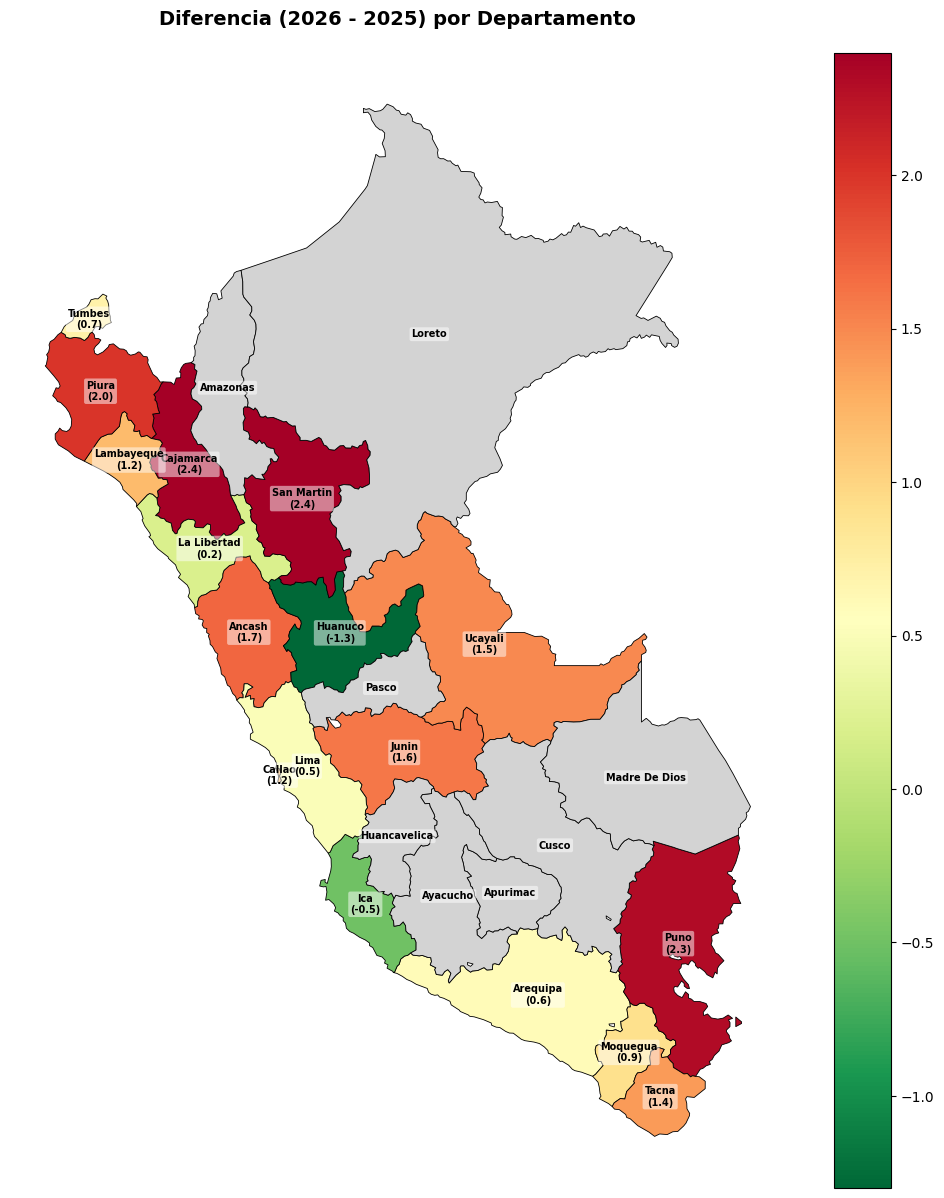

In [450]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# 1. Carga del GeoJSON departamental
gdf = gpd.read_file(
    "https://raw.githubusercontent.com/juaneladio/peru-geojson/master/peru_departamental_simple.geojson"
)

# 2. Asegurar el cruce correcto manteniendo la estructura espacial intacta (Left Join)
mapa = gdf.merge(
    dfx,
    left_on="NOMBDEP",
    right_on="DEPART",
    how="left"
)

# 3. Configuración del lienzo de visualización
fig, ax = plt.subplots(figsize=(10, 12))

# 4. Renderizado del mapa base con inversión de colormap (_r) -> Verde: bajo, Rojo: alto
mapa.plot(
    column="diff",
    cmap="RdYlGn_r",  # Inversión del gradiente de Red-Yellow-Green
    linewidth=0.6,
    edgecolor="black",
    missing_kwds={
        "color": "lightgray", 
        "label": "Sin Datos"
    },
    legend=True,
    ax=ax
)

# 5. Inclusión vectorizada de etiquetas (Nombre + Valor si existe)
for idx, row in mapa.iterrows():
    # Obtención de las coordenadas del centroide geométrico de cada región
    centroide = row.geometry.centroid
    x, y = centroide.x, centroide.y
    
    # Capitalizar de forma limpia el nombre del departamento (ej: "LIMA" -> "Lima")
    nombre_dep = str(row["NOMBDEP"]).title()
    
    # Si tiene métrica añade el valor abajo del nombre; si es NaN, solo coloca el nombre
    if pd.notna(row["diff"]):
        etiqueta = f"{nombre_dep}\n({row['diff']:.1f})"
    else:
        etiqueta = nombre_dep
        
    # Dibujar texto en el mapa con caja de fondo semitransparente para legibilidad
    ax.text(
        x, y, 
        etiqueta, 
        fontsize=7, 
        ha="center", 
        va="center",
        fontweight="bold",
        color="black",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.5, ec="none")
    )

# 6. Formato final y buenas prácticas de estilo
ax.set_title("Diferencia (2026 - 2025) por Departamento", fontsize=14, fontweight="bold", pad=20)
ax.axis("off")

plt.tight_layout()
plt.show()

In [451]:
dff_merge4

Año,Local,codigo_local,formato,ubicacion,cluster_comercial,supervisor,regional,m2,departamento,2025,2026,m2_segmentado,DEPART
0,Pvea Acho,P159,PLAZA VEA,Lima + Callao,BC2,VIK ENCISO,Sebastián Santangelo,3050.0,Lima,0.07530,0.04086,1333.75 - 3082.00,LIMA
1,Pvea Alfonso Ugarte,P118,PLAZA VEA,Lima + Callao,BC3,VIK ENCISO,Sebastián Santangelo,4358.0,Lima,0.03200,0.05552,4092.75 - 7079.00,LIMA
2,Pvea Arequipa,P104,PLAZA VEA,Provincia,BC3,JOE HUAMANCONDOR,Sofía Villanueva,4120.0,Arequipa,0.04364,0.05500,4092.75 - 7079.00,AREQUIPA
3,Pvea Ate,P066,PLAZA VEA,Lima + Callao,BC3,RODOLFO OLIVRY,Sebastián Santangelo,4798.0,Lima,0.03756,0.05058,4092.75 - 7079.00,LIMA
4,Pvea Aventura Sjl,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04782,0.05134,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,Viv Pardo,V019,VIVANDA,Lima + Callao,NaN,María Rojas,María Rojas,1111.0,Lima,NaN,0.08645,293.00 - 1333.75,LIMA
110,Viv Pezet,V090,VIVANDA,Lima + Callao,A1,María Rojas,María Rojas,920.0,Lima,0.05646,0.05424,293.00 - 1333.75,LIMA
111,Xvea Art Express,P422,PLAZA VEA SUPER,Lima + Callao,FP,Fátima León,Fátima León,713.0,Lima,0.02856,0.08190,293.00 - 1333.75,LIMA
112,Xvea Bolognesi,X209,PLAZA VEA EXPRESS,Lima + Callao,FP,Fátima León,Fátima León,343.0,Lima,0.07666,0.04516,293.00 - 1333.75,LIMA


In [452]:
dff_merge2["Local"].nunique()
dff_merge4["Local"].nunique()

114

In [ ]:
dff_merge4[dff_merge4["codigo_local"].isnull()]["Local"].unique()

dicc_final = {"Pvea Aventura Sjl":"1593","Pvea Chiclayo Mall":"P769", "Pvea Cuzco San Antonio":"1198", "Svea La Victoria":"P208", "Svea Ska":"P181", "Pvea Breña Centenario":""}

In [462]:
df_local["codigo_local"] = df_local["codigo_local"].astype(str)
# 1. Definir la lista de columnas que presentan valores faltantes
dff_merge4[dff_merge4["formato"].isnull()]

Año,Local,codigo_local,formato,ubicacion,cluster_comercial,supervisor,regional,m2,departamento,2025,2026,m2_segmentado,DEPART
4,Pvea Aventura Sjl,1593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04782,0.05134,NaN,NaN
8,Pvea Breña Centenario,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.07044,0.07692,NaN,NaN
14,Pvea Chiclayo Mall,P769,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.02146,0.06194,NaN,NaN
21,Pvea Cuzco San Antonio,1198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.06646,0.09804,NaN,NaN
37,Pvea La Placita,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.03590,0.05188,NaN,NaN
42,Pvea Nuevo Chimbote,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.02726,0.03998,NaN,NaN
51,Pvea Rimac,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.02494,0.08200,NaN,NaN
63,Pvea Talara Mall,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.03142,0.01826,NaN,NaN
80,Svea Cuzco Quoyllur,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.08350,0.09456,NaN,NaN
82,Svea El Tambo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.03460,0.07722,NaN,NaN


In [455]:
dff_merge4["codigo_local"] = dff_merge4["codigo_local"].fillna(dff_merge4["Local"].map(dicc_final))
dff_merge4

Año,Local,codigo_local,formato,ubicacion,cluster_comercial,supervisor,regional,m2,departamento,2025,2026,m2_segmentado,DEPART
0,Pvea Acho,P159,PLAZA VEA,Lima + Callao,BC2,VIK ENCISO,Sebastián Santangelo,3050.0,Lima,0.07530,0.04086,1333.75 - 3082.00,LIMA
1,Pvea Alfonso Ugarte,P118,PLAZA VEA,Lima + Callao,BC3,VIK ENCISO,Sebastián Santangelo,4358.0,Lima,0.03200,0.05552,4092.75 - 7079.00,LIMA
2,Pvea Arequipa,P104,PLAZA VEA,Provincia,BC3,JOE HUAMANCONDOR,Sofía Villanueva,4120.0,Arequipa,0.04364,0.05500,4092.75 - 7079.00,AREQUIPA
3,Pvea Ate,P066,PLAZA VEA,Lima + Callao,BC3,RODOLFO OLIVRY,Sebastián Santangelo,4798.0,Lima,0.03756,0.05058,4092.75 - 7079.00,LIMA
4,Pvea Aventura Sjl,1593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04782,0.05134,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,Viv Pardo,V019,VIVANDA,Lima + Callao,NaN,María Rojas,María Rojas,1111.0,Lima,NaN,0.08645,293.00 - 1333.75,LIMA
110,Viv Pezet,V090,VIVANDA,Lima + Callao,A1,María Rojas,María Rojas,920.0,Lima,0.05646,0.05424,293.00 - 1333.75,LIMA
111,Xvea Art Express,P422,PLAZA VEA SUPER,Lima + Callao,FP,Fátima León,Fátima León,713.0,Lima,0.02856,0.08190,293.00 - 1333.75,LIMA
112,Xvea Bolognesi,X209,PLAZA VEA EXPRESS,Lima + Callao,FP,Fátima León,Fátima León,343.0,Lima,0.07666,0.04516,293.00 - 1333.75,LIMA


In [456]:
dff_merge4.to_excel("reporte_final1.xlsx")

PermissionError: [Errno 13] Permission denied: 'reporte_final1.xlsx'